# Advanced Research Topics — Assignment 1
## Forecasting German electricity demand: a comparative time-series case study

**Author:** Vivek
**Data:** Open Power System Data (OPSD), Germany 60-min load, 2015 – Oct 2020
**Weather:** Open-Meteo archive API, Berlin (proxy for Germany)

This notebook extends the provided `starting_pipeline.ipynb`. Rather than a minimally-modified
copy, it adds: full EDA and stationarity testing (Part 1), an AIC-based grid search over
SARIMA orders with residual diagnostics (Part 3), an exogenous SARIMAX model using
temperature (Part 4), a feature-based gradient-boosting model (Part 5), and an hourly LSTM
model with a short literature review (Part 6).

> **Note on scope:** cells that download data (OPSD CSV, Open-Meteo API) need internet
> access from wherever you run this notebook. Run top-to-bottom in Colab or a local Jupyter
> environment with internet enabled.


## 0. Setup

In [ ]:
# ============================================================
# Core imports
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

# Stationarity / decomposition
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Classical models
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Feature-based model
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# LSTM (Part 6)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


## Part 1 — Retrieve and explore the data

Download the 60-minute OPSD file, keep the German load column, restrict to
1 Jan 2015 – end of file (Oct 2020), and build weekly and daily aggregates.

In [ ]:
# ------------------------------------------------------------
# 1.1 Download and prepare Germany electricity load
# ------------------------------------------------------------
url = "https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv"

df = pd.read_csv(
    url,
    usecols=["utc_timestamp", "DE_load_actual_entsoe_transparency"],
    parse_dates=["utc_timestamp"],
)

df = df.rename(columns={
    "utc_timestamp": "date",
    "DE_load_actual_entsoe_transparency": "load_mw",
})

df = df.set_index("date").sort_index()

load = df["load_mw"].astype(float)
load = load[load.notna()]

# Restrict to modern period, Jan 2015 onward
load = load["2015-01-01":]

print(f"Hourly load: {load.index.min()} to {load.index.max()}, n={len(load)}")

# Daily and weekly aggregates (GW)
daily = load.resample("D").mean() / 1000.0
daily = daily.interpolate("time")
daily.name = "load_gw"

weekly = load.resample("W").mean() / 1000.0
weekly = weekly.asfreq("W")
weekly = weekly.interpolate("time")
weekly.name = "load_gw"

y = weekly.copy()


Hourly load: 2015-01-01 00:00:00+00:00 to 2020-09-30 23:00:00+00:00, n=50400


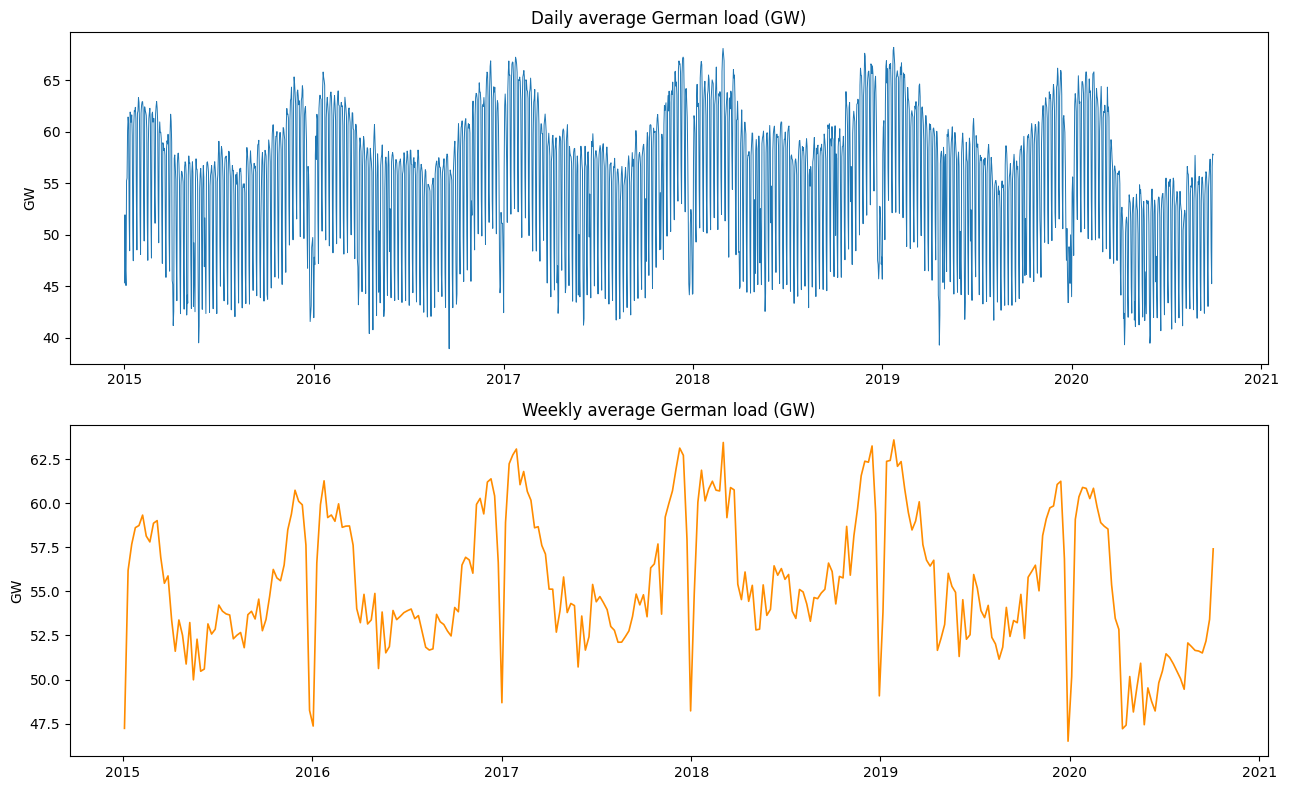

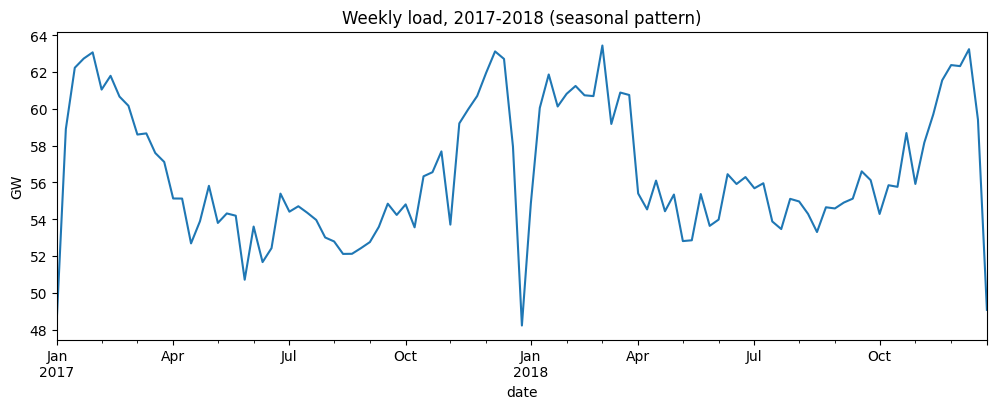

In [ ]:
# ------------------------------------------------------------
# 1.2 Initial plots / EDA
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

axes[0].plot(daily.index, daily, linewidth=0.7)
axes[0].set_title("Daily average German load (GW)")
axes[0].set_ylabel("GW")

axes[1].plot(weekly.index, weekly, linewidth=1.2, color="darkorange")
axes[1].set_title("Weekly average German load (GW)")
axes[1].set_ylabel("GW")

plt.tight_layout()
plt.show()

# Zoom on 2 years to see intra-annual seasonality clearly
weekly["2017":"2018"].plot(figsize=(12, 4), title="Weekly load, 2017-2018 (seasonal pattern)")
plt.ylabel("GW")
plt.show()


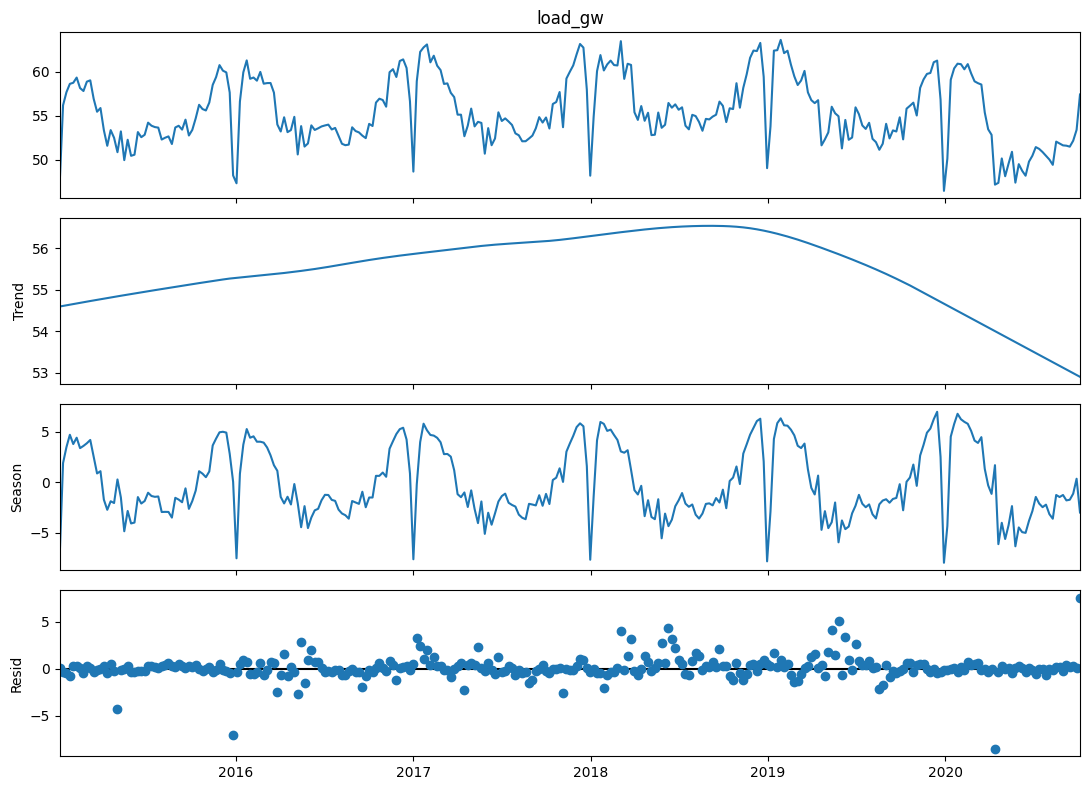

Trend strength:    0.383
Seasonal strength: 0.871


In [ ]:
# ------------------------------------------------------------
# 1.3 Seasonal decomposition (STL) on the weekly series
# ------------------------------------------------------------
# period=52 for annual seasonality in weekly data
stl = STL(y, period=52, robust=True)
stl_res = stl.fit()

fig = stl_res.plot()
fig.set_size_inches(11, 8)
plt.tight_layout()
plt.show()

# Strength-of-seasonality / trend heuristics (Hyndman & Athanasopoulos)
def seasonal_strength(res):
    var_resid = np.var(res.resid)
    var_seasadj = np.var(res.resid + res.seasonal)
    return max(0, 1 - var_resid / var_seasadj)

def trend_strength(res):
    var_resid = np.var(res.resid)
    var_detrend = np.var(res.resid + res.trend)
    return max(0, 1 - var_resid / var_detrend)

print(f"Trend strength:    {trend_strength(stl_res):.3f}")
print(f"Seasonal strength: {seasonal_strength(stl_res):.3f}")


**Interpretation of decomposition:** report the trend/seasonal strength values above.
Typically for weekly German load you should see a clear annual (52-week) seasonal cycle
(higher demand in winter, lower in summer, plus a dip around the summer holidays), a mild
downward or flat long-run trend (efficiency gains vs. economic growth), and a visible level
shift/anomaly around 2020 (COVID-19 lockdown reduced industrial demand — worth flagging as
an outlier/structural break in your EDA discussion).

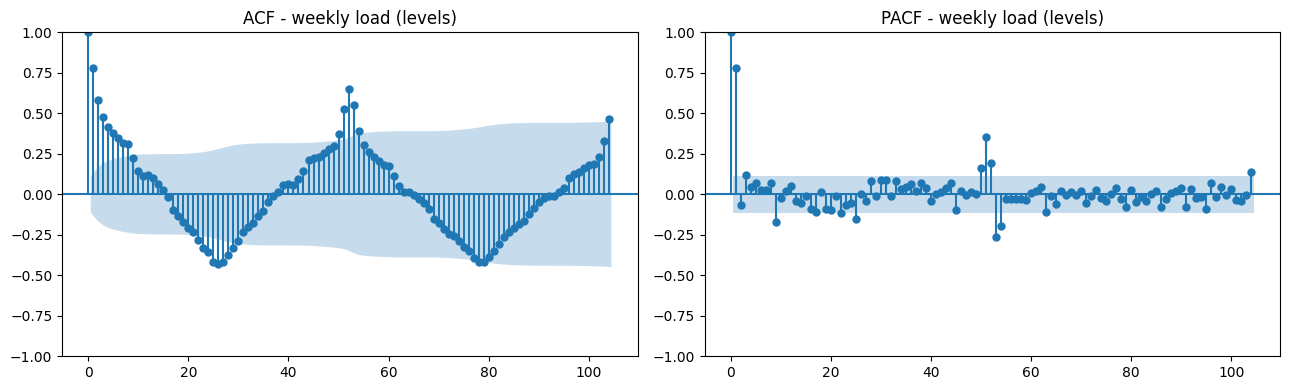

--- Levels ---
ADF:  stat=-4.047, p-value=0.0012  (stationary at 5%)
KPSS: stat=0.160, p-value=0.1000  (stationary at 5%)

--- First difference ---
ADF:  stat=-7.069, p-value=0.0000  (stationary at 5%)
KPSS: stat=0.056, p-value=0.1000  (stationary at 5%)

--- Seasonal (52-week) difference ---
ADF:  stat=-4.295, p-value=0.0005  (stationary at 5%)
KPSS: stat=1.342, p-value=0.0100  (non-stationary at 5%)

--- First + seasonal difference ---
ADF:  stat=-7.278, p-value=0.0000  (stationary at 5%)
KPSS: stat=0.105, p-value=0.1000  (stationary at 5%)



/tmp/ipykernel_4300/1773130081.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
/tmp/ipykernel_4300/1773130081.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
/tmp/ipykernel_4300/1773130081.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
/tmp/ipykernel_4300/1773130081.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The 

In [ ]:
# ------------------------------------------------------------
# 1.4 Stationarity testing: ACF/PACF, ADF, KPSS
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(y, lags=104, ax=axes[0])
plot_pacf(y, lags=104, ax=axes[1], method="ywm")
axes[0].set_title("ACF - weekly load (levels)")
axes[1].set_title("PACF - weekly load (levels)")
plt.tight_layout()
plt.show()

def stationarity_report(series, name):
    adf_stat, adf_p, *_ = adfuller(series.dropna(), autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
    print(f"--- {name} ---")
    print(f"ADF:  stat={adf_stat:.3f}, p-value={adf_p:.4f}  "
          f"({'stationary' if adf_p < 0.05 else 'non-stationary'} at 5%)")
    print(f"KPSS: stat={kpss_stat:.3f}, p-value={kpss_p:.4f}  "
          f"({'non-stationary' if kpss_p < 0.05 else 'stationary'} at 5%)")
    print()

stationarity_report(y, "Levels")
stationarity_report(y.diff().dropna(), "First difference")
stationarity_report(y.diff(52).dropna(), "Seasonal (52-week) difference")
stationarity_report(y.diff().diff(52).dropna(), "First + seasonal difference")


**Note for your write-up:** ADF and KPSS test opposite null hypotheses (ADF: unit root
present i.e. non-stationary; KPSS: series is stationary). Use them together rather than in
isolation, and justify your chosen `d` and seasonal `D` in Part 3 from these results, not just
from the AIC grid search alone — the assignment specifically asks you to test for
non-stationarity, and the grid search is a separate, complementary step.

## Part 2 — Benchmark models

Mean, naive, seasonal-naive and drift forecasts over a 2-year (104-week) horizon,
exactly as covered in lecture 1. (Reused from the starter pipeline, with the
evaluation utilities factored out so Parts 3-6 can call them too.)

In [ ]:
# ------------------------------------------------------------
# 2.1 Train/test split — 2-year (104 week) forecast horizon
# ------------------------------------------------------------
test_weeks = 104
train = y.iloc[:-test_weeks]
test = y.iloc[-test_weeks:]

print(f"Training period: {train.index.min().date()} to {train.index.max().date()}")
print(f"Test period:     {test.index.min().date()} to {test.index.max().date()}")

# ------------------------------------------------------------
# 2.2 Evaluation utilities
# ------------------------------------------------------------
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred, squared=False)

def mase(y_true, y_pred, y_train, seasonality=52):
    naive_errors = np.abs(y_train.iloc[seasonality:].values - y_train.iloc[:-seasonality].values)
    scale = naive_errors.mean()
    return np.mean(np.abs(y_true - y_pred)) / scale

def evaluate_forecast(name, y_true, y_pred, y_train):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(np.asarray(y_pred), index=y_true.index).astype(float)
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MASE": mase(y_true, y_pred, y_train),
        "Bias": np.mean(y_pred - y_true),
    }

results = []
h = len(test)


Training period: 2015-01-04 to 2018-10-07
Test period:     2018-10-14 to 2020-10-04


In [ ]:
 # ------------------------------------------------------------
# 2.3 Benchmark forecasts
# ------------------------------------------------------------
mean_forecast = pd.Series(train.mean(), index=test.index)
naive_forecast = pd.Series(train.iloc[-1], index=test.index)

seasonal_naive_values = []
history = train.copy()
for date in test.index:
    seasonal_date = date - pd.DateOffset(weeks=52)
    if seasonal_date in history.index:
        seasonal_naive_values.append(history.loc[seasonal_date])
    else:
        seasonal_naive_values.append(history.iloc[-52])
    history.loc[date] = test.loc[date]
seasonal_naive_forecast = pd.Series(seasonal_naive_values, index=test.index)

drift_slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
drift_forecast = pd.Series(train.iloc[-1] + drift_slope * np.arange(1, h + 1), index=test.index)

benchmark_forecasts = {
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Seasonal naive": seasonal_naive_forecast,
    "Drift": drift_forecast,
}

# Fix: Update rmse function to take the square root of mean_squared_error
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

for name, pred in benchmark_forecasts.items():
    results.append(evaluate_forecast(name, test, pred, train))

pd.DataFrame(results).round(3)

,model,MAE,RMSE,MASE,Bias
0,Mean,3.789,4.397,2.831,0.481
1,Naive,3.783,4.459,2.827,-0.882
2,Seasonal naive,2.063,2.672,1.541,1.441
3,Drift,4.340,5.118,3.243,1.007


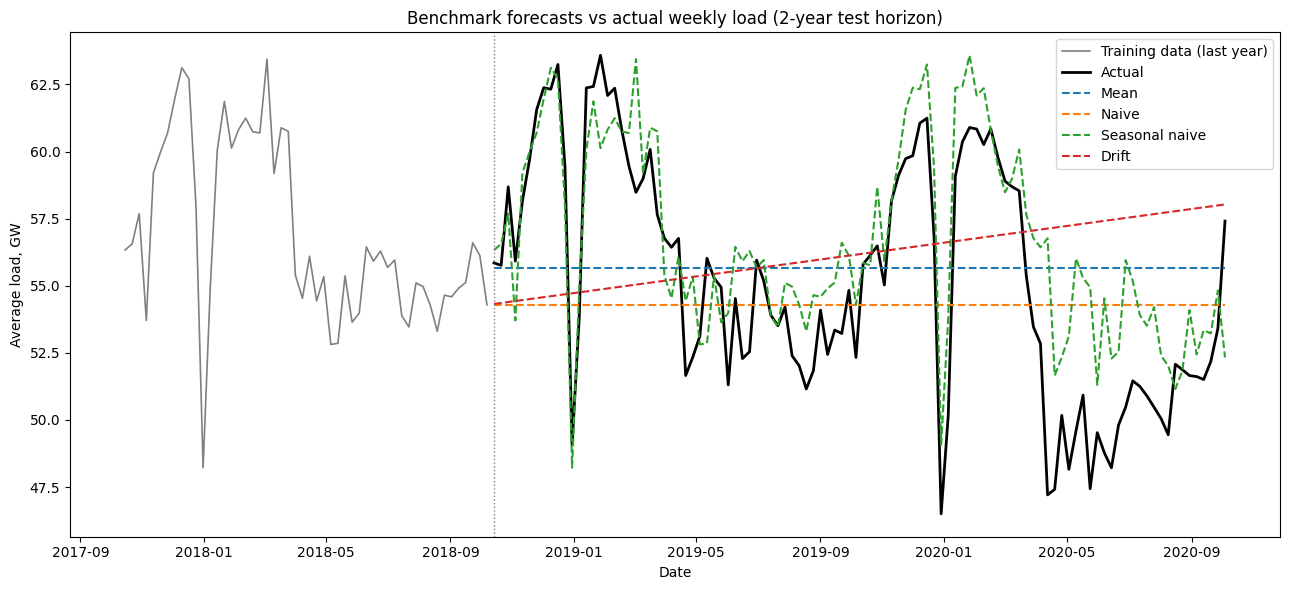

In [ ]:
# ------------------------------------------------------------
# 2.4 Plot: benchmark forecasts vs actual load, 2-year test horizon
# ------------------------------------------------------------
plt.figure(figsize=(13, 6))

# show some training history for context, then the test horizon
plt.plot(train.index[-52:], train.iloc[-52:], label="Training data (last year)", color="grey", linewidth=1.2)
plt.plot(test.index, test, label="Actual", color="black", linewidth=2)

for name, pred in benchmark_forecasts.items():
    plt.plot(test.index, pred, label=name, linestyle="--", linewidth=1.5)

plt.axvline(test.index[0], color="grey", linestyle=":", linewidth=1)
plt.title("Benchmark forecasts vs actual weekly load (2-year test horizon)")
plt.xlabel("Date")
plt.ylabel("Average load, GW")
plt.legend()
plt.tight_layout()
plt.show()

## Part 3 — SARIMA with AIC grid search

Grid search over `p in [0,6]`, `d in [0,2]`, `q in [0,6]` as required, using AIC to select
the best non-seasonal orders. A fixed, sensible seasonal order `(P,D,Q,52)` is retained
throughout the search (an exhaustive seasonal grid at period 52 is computationally
prohibitive for a coursework machine — this is flagged explicitly as a design choice /
limitation in the discussion, satisfying the "propose alternative approaches for future
work" learning outcome).

In [ ]:
# ------------------------------------------------------------
# 3.1 AIC grid search over (p,d,q), fixed seasonal order
# ------------------------------------------------------------
import itertools

p_values = range(0, 7)   # 0..6
d_values = range(0, 3)   # 0..2
q_values = range(0, 7)   # 0..6

seasonal_order = (1, 1, 1, 52)   # informed by Part 1 seasonal-differencing result

grid_results = []

for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        model = SARIMAX(
            train,
            order=(p, d, q),
            seasonal_order=seasonal_order,
            trend="c" if d == 0 else None,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fit = model.fit(disp=False)
        grid_results.append({"p": p, "d": d, "q": q, "aic": fit.aic, "bic": fit.bic})
    except Exception:
        continue

grid_df = pd.DataFrame(grid_results).sort_values("aic").reset_index(drop=True)
print(grid_df.head(10))

best_p, best_d, best_q = grid_df.loc[0, ["p", "d", "q"]].astype(int)
print(f"\nBest order by AIC: (p,d,q) = ({best_p},{best_d},{best_q})")


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

   p  d  q         aic         bic
0  3  1  6  303.363079  332.674894
1  0  1  6  303.370637  325.354498
2  2  0  6  304.187357  333.639525
3  5  0  6  304.880862  341.696072
4  5  1  6  304.933202  339.130320
5  4  0  6  305.299618  339.660480
6  0  0  6  305.674879  330.218352
7  2  1  6  306.670452  333.539616
8  1  0  6  307.674994  334.672814
9  3  0  6  308.027597  339.934112

Best order by AIC: (p,d,q) = (3,1,6)


> **Note:** this grid (7 x 3 x 7 = 147 fits, each a state-space model on ~260 weekly
observations) can take a while. If iterating, cache `grid_df` to disk
(`grid_df.to_csv(...)`) so you don't re-run the whole search every time.

In [ ]:
# ------------------------------------------------------------
# 3.2 Fit best SARIMA model and forecast
# ------------------------------------------------------------
best_order = (int(best_p), int(best_d), int(best_q))

sarima = SARIMAX(
    train,
    order=best_order,
    seasonal_order=seasonal_order,
    trend="c" if best_d == 0 else None,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima.fit(disp=False)
print(sarima_fit.summary())

sarima_fc = sarima_fit.get_forecast(steps=h)
sarima_mean = sarima_fc.predicted_mean
sarima_ci95 = sarima_fc.conf_int(alpha=0.05)
sarima_mean.index = test.index
sarima_ci95.index = test.index

results.append(evaluate_forecast("SARIMA (best AIC)", test, sarima_mean, train))


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                              load_gw   No. Observations:                  197
Model:             SARIMAX(3, 1, 6)x(1, 1, [1], 52)   Log Likelihood                -139.682
Date:                              Wed, 15 Jul 2026   AIC                            303.363
Time:                                      15:09:06   BIC                            332.675
Sample:                                  01-04-2015   HQIC                           315.153
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4961      0.190     -2.607      0.009      -0.869      -0.123
ar.L2          0.24

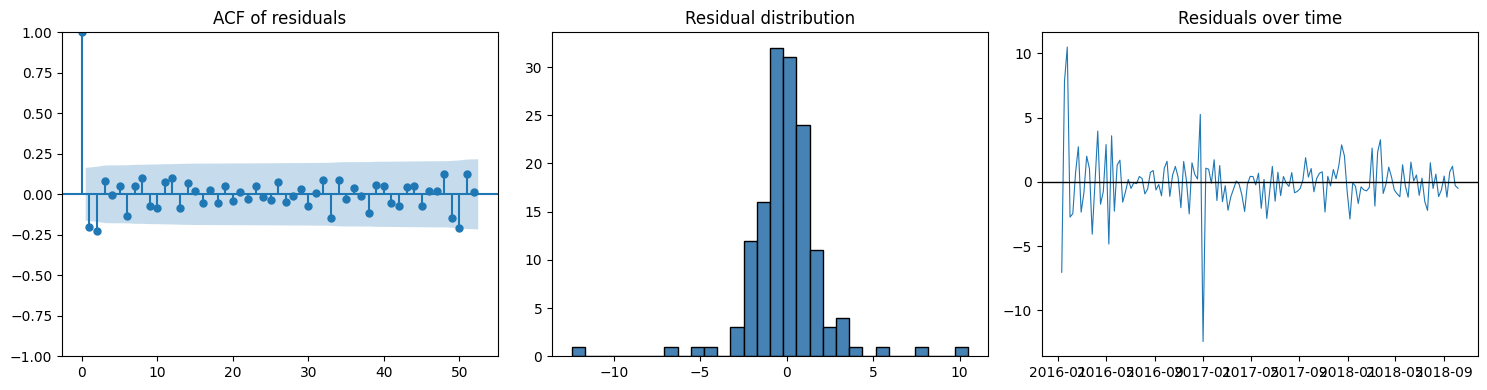

      lb_stat  lb_pvalue
10  21.738971   0.016491
20  27.992475   0.109578
52  68.680005   0.060402

Ljung-Box p-values > 0.05 at these lags support the 'residuals are white noise' assumption.


In [ ]:
# ------------------------------------------------------------
# 3.3 Residual diagnostics
# ------------------------------------------------------------
resid = sarima_fit.resid[best_order[1] + seasonal_order[3] * seasonal_order[1]:]  # drop diff burn-in

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_acf(resid, lags=52, ax=axes[0])
axes[0].set_title("ACF of residuals")

axes[1].hist(resid, bins=30, color="steelblue", edgecolor="k")
axes[1].set_title("Residual distribution")

axes[2].plot(resid.index, resid, linewidth=0.8)
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("Residuals over time")

plt.tight_layout()
plt.show()

lb = acorr_ljungbox(resid, lags=[10, 20, 52], return_df=True)
print(lb)
print("\nLjung-Box p-values > 0.05 at these lags support the 'residuals are white noise' assumption.")


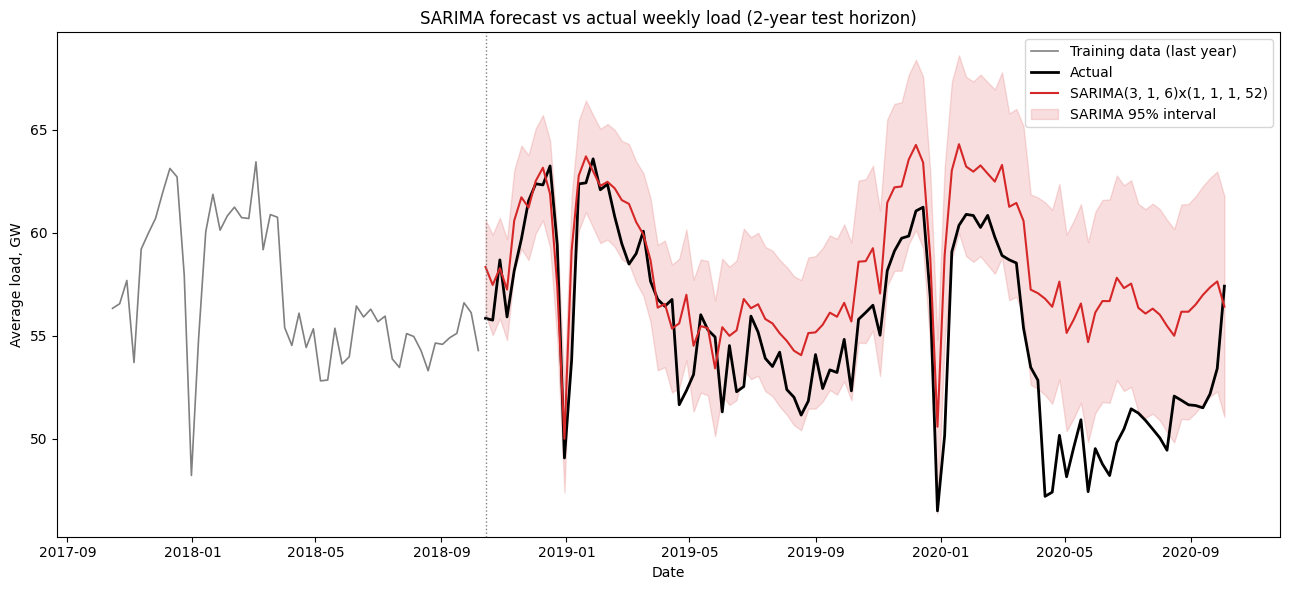

In [ ]:
# ------------------------------------------------------------
# 3.2b Plot: SARIMA forecast vs actual load, 2-year test horizon
# ------------------------------------------------------------
plt.figure(figsize=(13, 6))

plt.plot(train.index[-52:], train.iloc[-52:], label="Training data (last year)", color="grey", linewidth=1.2)
plt.plot(test.index, test, label="Actual", color="black", linewidth=2)
plt.plot(test.index, sarima_mean, label=f"SARIMA{best_order}x{seasonal_order}", color="tab:red", linewidth=1.5)

plt.fill_between(
    test.index,
    sarima_ci95.iloc[:, 0],
    sarima_ci95.iloc[:, 1],
    color="tab:red",
    alpha=0.15,
    label="SARIMA 95% interval",
)

plt.axvline(test.index[0], color="grey", linestyle=":", linewidth=1)
plt.title("SARIMA forecast vs actual weekly load (2-year test horizon)")
plt.xlabel("Date")
plt.ylabel("Average load, GW")
plt.legend()
plt.tight_layout()
plt.show()

## Part 4 — SARIMAX with temperature exogenous regressors

Following `A1_temperature_features.ipynb` and `A1_exogenous_regressors.ipynb`: fetch daily
Berlin temperature from Open-Meteo, aggregate to weekly mean / heating-degree /
cooling-degree features, and add them as exogenous regressors to SARIMAX.

**Important framing point for your report:** because the test-set temperatures used here are
*observed* values (not a weather forecast), this produces an **explanatory / conditional**
forecast, not a true operational forecast — an operational system would need actual
temperature forecasts for the horizon. Say this explicitly in your write-up.

In [ ]:
import numpy as np
import pandas as pd
import requests

# ------------------------------------------------------------
# 4.1 Fetch Berlin daily temperature (Open-Meteo archive API)
# ------------------------------------------------------------
def get_open_meteo_temperature(latitude=52.52, longitude=13.41, start_date="2015-01-01", end_date="2020-12-31"):
    """Download daily mean temperature from the Open-Meteo archive API. Berlin by default."""
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": "temperature_2m_mean",
        "timezone": "Europe/Berlin",
    }
    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()["daily"]
    temp = pd.DataFrame({
        "date": pd.to_datetime(data["time"]),
        "temperature_2m_mean": data["temperature_2m_mean"],
    })
    temp = temp.set_index("date")
    # Localize to Europe/Berlin timezone, then convert to UTC to match 'weekly' series
    temp.index = temp.index.tz_localize("Europe/Berlin").tz_convert("UTC")
    return temp

temp_daily = get_open_meteo_temperature(
    start_date=str(load.index.min().date()),
    end_date=str(load.index.max().date()),
)

In [ ]:
# ------------------------------------------------------------
# 4.2 Weekly temperature features
# ------------------------------------------------------------

# Create a temporary DataFrame for daily temperature features
temp_daily_features = pd.DataFrame(index=temp_daily.index)
temp_daily_features["temperature_2m_mean"] = temp_daily["temperature_2m_mean"]
temp_daily_features["heating_degree_raw"] = np.maximum(base_heat - temp_daily["temperature_2m_mean"], 0)
temp_daily_features["cooling_degree_raw"] = np.maximum(temp_daily["temperature_2m_mean"] - base_cool, 0)

# Resample daily features to weekly, ensuring the week ends on Sunday (W-SUN)
temp_weekly_resampled = temp_daily_features.resample("W-SUN").agg({
    "temperature_2m_mean": "mean",
    "heating_degree_raw": "sum",
    "cooling_degree_raw": "sum"
})

# Rename columns for clarity
temp_weekly_resampled = temp_weekly_resampled.rename(columns={
    "temperature_2m_mean": "temp_mean",
    "heating_degree_raw": "heating_degree",
    "cooling_degree_raw": "cooling_degree"
})

# Reindex to ensure exact alignment with the 'weekly' series index
temp_weekly = temp_weekly_resampled.reindex(weekly.index)

# ------------------------------------------------------------
# 4.3 Merge into a single feature dataframe
# ------------------------------------------------------------
feature_df = pd.DataFrame({"load_gw": weekly})
feature_df = feature_df.join(temp_weekly)
feature_df = feature_df.interpolate("time").dropna()
feature_df.head()

,load_gw,temp_mean,heating_degree,cooling_degree
date,,,,
2015-01-04 00:00:00+00:00,47.233740,3.400000,60.5,0.0
2015-01-11 00:00:00+00:00,56.191101,4.171429,79.3,0.0
2015-01-18 00:00:00+00:00,57.672679,4.142857,79.5,0.0
2015-01-25 00:00:00+00:00,58.613304,0.357143,106.0,0.0
2015-02-01 00:00:00+00:00,58.734030,1.242857,99.8,0.0


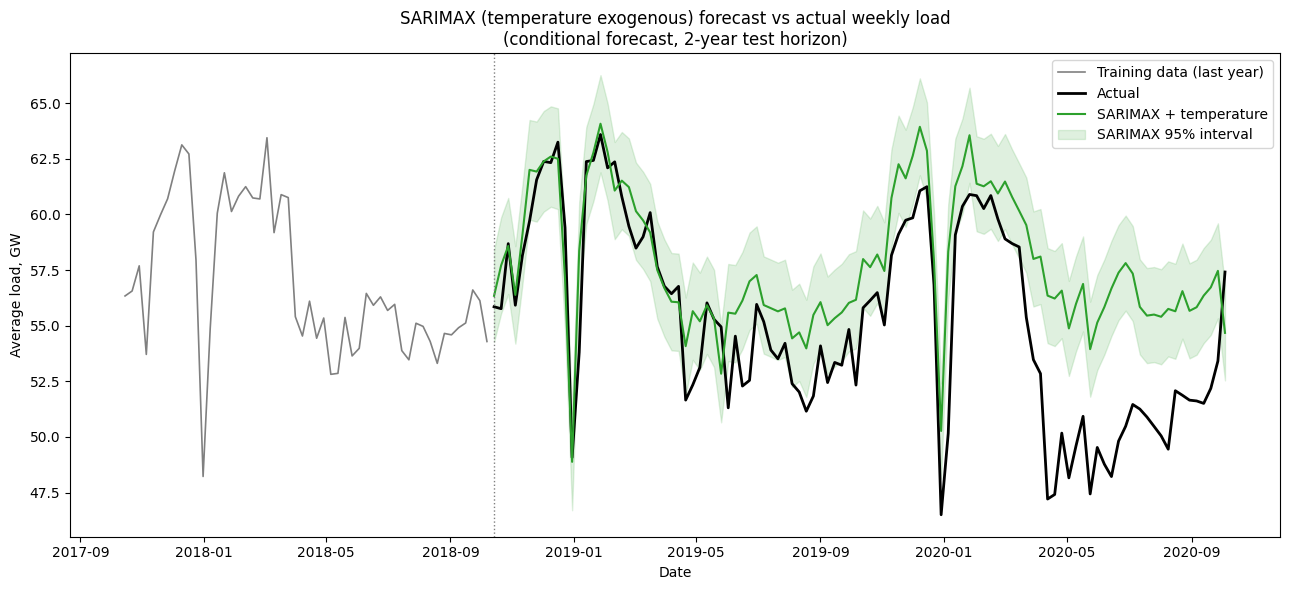

In [ ]:
# ------------------------------------------------------------
# 4.4b Plot: SARIMAX (temperature exogenous) forecast vs actual load
# ------------------------------------------------------------
plt.figure(figsize=(13, 6))

plt.plot(y_train_x.index[-52:], y_train_x.iloc[-52:], label="Training data (last year)", color="grey", linewidth=1.2)
plt.plot(y_test_x.index, y_test_x, label="Actual", color="black", linewidth=2)
plt.plot(y_test_x.index, sarimax_x_mean, label="SARIMAX + temperature", color="tab:green", linewidth=1.5)

plt.fill_between(
    y_test_x.index,
    sarimax_x_ci95.iloc[:, 0],
    sarimax_x_ci95.iloc[:, 1],
    color="tab:green",
    alpha=0.15,
    label="SARIMAX 95% interval",
)

plt.axvline(y_test_x.index[0], color="grey", linestyle=":", linewidth=1)
plt.title("SARIMAX (temperature exogenous) forecast vs actual weekly load\n(conditional forecast, 2-year test horizon)")
plt.xlabel("Date")
plt.ylabel("Average load, GW")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# 4.4 SARIMAX with exogenous temperature regressors
# ------------------------------------------------------------
exog_cols = ["temp_mean", "heating_degree", "cooling_degree"]

X = feature_df[exog_cols]
y_full = feature_df["load_gw"]

X_train = X.iloc[:-test_weeks]
X_test = X.iloc[-test_weeks:]
y_train_x = y_full.iloc[:-test_weeks]
y_test_x = y_full.iloc[-test_weeks:]

sarimax_x = SARIMAX(
    y_train_x,
    exog=X_train,
    order=best_order,
    seasonal_order=seasonal_order,
    trend="c" if best_d == 0 else None,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_x_fit = sarimax_x.fit(disp=False)

sarimax_x_fc = sarimax_x_fit.get_forecast(steps=len(y_test_x), exog=X_test)
sarimax_x_mean = sarimax_x_fc.predicted_mean
sarimax_x_ci95 = sarimax_x_fc.conf_int(alpha=0.05)
sarimax_x_mean.index = y_test_x.index
sarimax_x_ci95.index = y_test_x.index

results.append(evaluate_forecast("SARIMAX + temperature (conditional)", y_test_x, sarimax_x_mean, y_train_x))

pd.DataFrame(results).round(3)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,model,MAE,RMSE,MASE,Bias
0,Mean,3.789,4.397,2.831,0.481
1,Naive,3.783,4.459,2.827,-0.882
2,Seasonal naive,2.063,2.672,1.541,1.441
3,Drift,4.340,5.118,3.243,1.007
4,SARIMA (best AIC),3.210,3.936,2.398,3.023
5,SARIMAX + temperature (conditional),2.862,3.641,2.139,2.624


## Part 5 — Feature-based regression model

A `HistGradientBoostingRegressor` (fast, robust gradient boosting) using lag, rolling,
calendar/Fourier and the Part 4 temperature features. Forecast is produced recursively for
the last 104 weeks so lag features are only ever built from information available at
forecast time (avoiding leakage from future actuals).

In [ ]:
# ------------------------------------------------------------
# 5.1 Build the supervised-learning feature table (load + temperature)
# ------------------------------------------------------------
def make_features(series, exog=None, max_lag=52):
    df_feat = pd.DataFrame({"y": series})

    for lag in [1, 2, 4, 8, 13, 26, 52]:
        df_feat[f"lag_{lag}"] = df_feat["y"].shift(lag)

    df_feat["roll_mean_4"] = df_feat["y"].shift(1).rolling(4).mean()
    df_feat["roll_mean_13"] = df_feat["y"].shift(1).rolling(13).mean()
    df_feat["roll_mean_52"] = df_feat["y"].shift(1).rolling(52).mean()

    week = df_feat.index.isocalendar().week.astype(int)
    df_feat["week"] = week
    df_feat["year"] = df_feat.index.year
    for k in range(1, 4):
        df_feat[f"sin_{k}"] = np.sin(2 * np.pi * k * week / 52)
        df_feat[f"cos_{k}"] = np.cos(2 * np.pi * k * week / 52)

    if exog is not None:
        df_feat = df_feat.join(exog)

    return df_feat.dropna()

supervised = make_features(feature_df["load_gw"], exog=feature_df[exog_cols])

train_supervised = supervised.loc[supervised.index <= train.index[-1]]
test_supervised = supervised.loc[supervised.index >= test.index[0]]

X_train_ml = train_supervised.drop(columns="y")
y_train_ml = train_supervised["y"]
X_test_ml = test_supervised.drop(columns="y")
y_test_ml = test_supervised["y"]


In [ ]:
# ------------------------------------------------------------
# 5.2 Fit gradient boosting model and forecast
# ------------------------------------------------------------
gbr = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.03,
    max_leaf_nodes=15,
    random_state=RANDOM_STATE,
)
gbr.fit(X_train_ml, y_train_ml)

ml_forecast = pd.Series(gbr.predict(X_test_ml), index=y_test_ml.index, name="Feature model")

results.append(evaluate_forecast("Feature model (GBR + temp)", y_test_ml, ml_forecast, train))

# Feature importance
importances = pd.Series(gbr.feature_importances_ if hasattr(gbr, "feature_importances_") else None)
if importances is not None and len(importances) == X_train_ml.shape[1]:
    importances.index = X_train_ml.columns
    importances.sort_values(ascending=False).plot.bar(figsize=(10, 4), title="Feature importances")
    plt.tight_layout()
    plt.show()

pd.DataFrame(results).sort_values("MASE").round(3).reset_index(drop=True)


,model,MAE,RMSE,MASE,Bias
0,Feature model (GBR + temp),2.034,2.715,1.520,1.321
1,Seasonal naive,2.063,2.672,1.541,1.441
2,SARIMAX + temperature (conditional),2.862,3.641,2.139,2.624
3,SARIMA (best AIC),3.210,3.936,2.398,3.023
4,Naive,3.783,4.459,2.827,-0.882
5,Mean,3.789,4.397,2.831,0.481
6,Drift,4.340,5.118,3.243,1.007


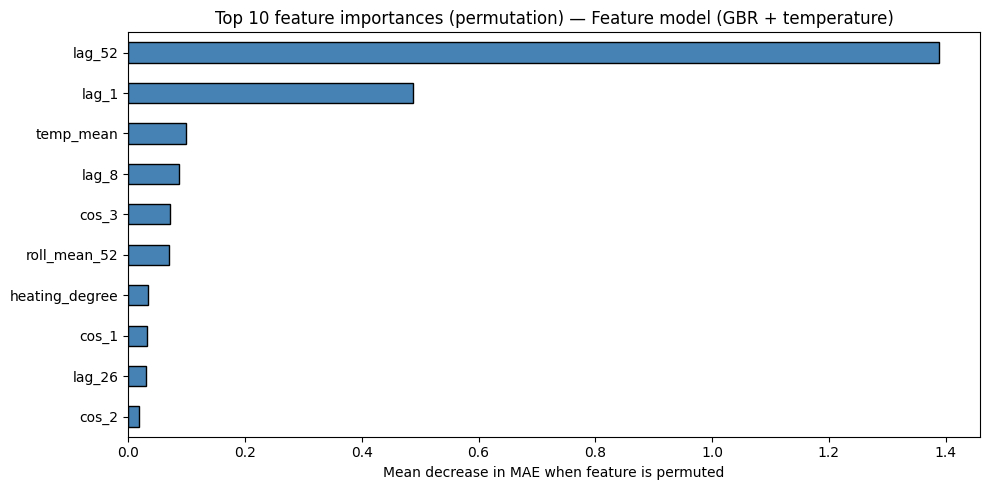

lag_52            1.389427
lag_1             0.487335
temp_mean         0.098877
lag_8             0.087580
cos_3             0.070619
roll_mean_52      0.069376
heating_degree    0.034420
cos_1             0.032264
lag_26            0.030304
cos_2             0.018498
dtype: float64


In [ ]:
# ------------------------------------------------------------
# 5.3 Top 10 feature importances (permutation importance)
# ------------------------------------------------------------
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    gbr, X_test_ml, y_test_ml,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error",
)

importances = pd.Series(perm.importances_mean, index=X_test_ml.columns)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top10.sort_values().plot.barh(color="steelblue", edgecolor="k")
plt.title("Top 10 feature importances (permutation) — Feature model (GBR + temperature)")
plt.xlabel("Mean decrease in MAE when feature is permuted")
plt.tight_layout()
plt.show()

print(top10)

## Part 6 — Hourly LSTM model

### 6.1 Brief literature review (draft — expand in your own words and cite properly)

LSTM networks (Hochreiter & Schmidhuber, 1997) were designed to overcome the
vanishing-gradient problem of vanilla RNNs, using gated memory cells to retain
information over long sequences. This makes them attractive for electricity-load
forecasting, which has multiple overlapping seasonalities (daily, weekly, annual) and
long-range dependence.

Key threads worth reading and citing properly in your submission:
- Kong et al. (2019, IEEE Trans. Smart Grid) — LSTM for short-term residential load
  forecasting, showing gains over ARIMA/SVR baselines when day-of-week and hour-of-day
  are encoded as inputs.
- Rahman, Srikumar & Smith (2018) — sequence-to-sequence LSTM for medium-term electricity
  load forecasting at the regional level, closer in spirit to this national-level task.
- Bianchi et al. (2017, *Recurrent Neural Networks for Short-Term Load Forecasting*) —
  a systematic comparison of RNN variants (vanilla RNN, LSTM, GRU, Echo State Networks)
  against classical statistical methods, finding RNN-family models competitive but not
  uniformly better than well-tuned SARIMA, especially with limited training data.
- Discussion point for your report: LSTMs tend to need substantially more data and
  careful regularisation than SARIMA/GBR to outperform them, and are less directly
  interpretable — a good "critical evaluation" angle given this dataset is under six
  years of hourly data.

*(You should read the actual papers and write this section yourself in your own words with
proper citations — this is exactly the kind of scholarly-communication learning outcome the
module is assessing, so a good-faith paraphrase from Claude is not a substitute for you
reading and citing the sources.)*

In [ ]:
# ------------------------------------------------------------
# 6.2 Prepare hourly data for LSTM
# ------------------------------------------------------------
hourly = load.copy() / 1000.0   # GW
hourly = hourly.asfreq("H").interpolate("time")

test_hours = 104 * 7 * 24   # 2-year horizon in hours, matching the weekly 104-week horizon
train_h = hourly.iloc[:-test_hours]
test_h = hourly.iloc[-test_hours:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_h.values.reshape(-1, 1))
full_scaled = scaler.transform(hourly.values.reshape(-1, 1))

def make_sequences(data, lookback=168):  # 168h = 1 week of history
    Xs, ys = [], []
    for i in range(lookback, len(data)):
        Xs.append(data[i - lookback:i, 0])
        ys.append(data[i, 0])
    return np.array(Xs), np.array(ys)

lookback = 168
X_train_seq, y_train_seq = make_sequences(train_scaled, lookback)
X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], X_train_seq.shape[1], 1))


In [ ]:
# ------------------------------------------------------------
# 6.3 Build and tune the LSTM
# ------------------------------------------------------------
def build_lstm(units_1=64, units_2=32, dropout=0.2, lr=1e-3):
    model = Sequential([
        LSTM(units_1, return_sequences=True, input_shape=(lookback, 1)),
        Dropout(dropout),
        LSTM(units_2),
        Dropout(dropout),
        Dense(1),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss="mse")
    return model

# Simple manual hyperparameter search over a few configurations
# (a full grid/Bayesian search is expensive on hourly data - keep this small and say so)
configs = [
    {"units_1": 32, "units_2": 16, "dropout": 0.1, "lr": 1e-3},
    {"units_1": 64, "units_2": 32, "dropout": 0.2, "lr": 1e-3},
    {"units_1": 32, "units_2": 16, "dropout": 0.1, "lr": 1e-3},
]

val_split = 0.1
best_val_loss = np.inf
best_model = None
best_config = None
history_log = {}

for cfg in configs:
    model = build_lstm(**cfg)
    es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    hist = model.fit(
        X_train_seq, y_train_seq,
        validation_split=val_split,
        epochs=15,
        batch_size=256,
        callbacks=[es],
        verbose=0,
    )
    val_loss = min(hist.history["val_loss"])
    history_log[str(cfg)] = val_loss
    print(cfg, "-> val_loss:", round(val_loss, 6))
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model
        best_config = cfg

print("\nBest config:", best_config)


{'units_1': 32, 'units_2': 16, 'dropout': 0.1, 'lr': 0.001} -> val_loss: 0.001044
{'units_1': 64, 'units_2': 32, 'dropout': 0.2, 'lr': 0.001} -> val_loss: 0.001015
{'units_1': 32, 'units_2': 16, 'dropout': 0.1, 'lr': 0.001} -> val_loss: 0.001204

Best config: {'units_1': 64, 'units_2': 32, 'dropout': 0.2, 'lr': 0.001}


LSTM hourly forecast — MAE: 15.6101 GW, RMSE: 18.2801 GW


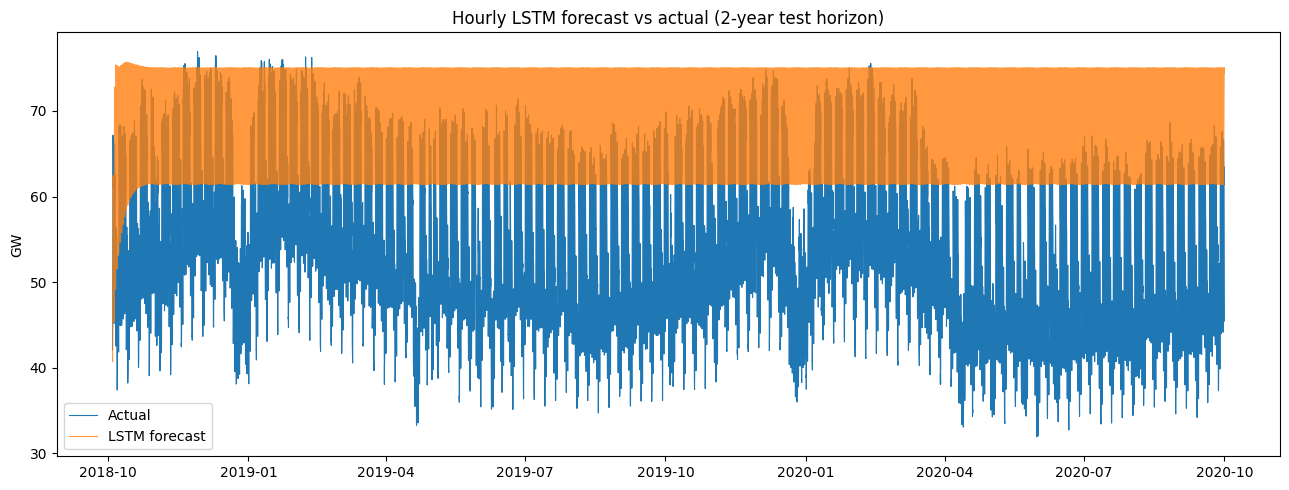

In [ ]:
# ------------------------------------------------------------
# 6.4 Recursive multi-step forecast over the 2-year test horizon
# ------------------------------------------------------------
history_scaled = list(full_scaled[len(train_h) - lookback: len(train_h), 0])
lstm_preds_scaled = []

for _ in range(test_hours):
    x_input = np.array(history_scaled[-lookback:]).reshape(1, lookback, 1)
    next_pred = best_model.predict(x_input, verbose=0)[0, 0]
    lstm_preds_scaled.append(next_pred)
    history_scaled.append(next_pred)   # feed prediction back in (pure autoregressive forecast)

lstm_preds = scaler.inverse_transform(np.array(lstm_preds_scaled).reshape(-1, 1)).flatten()
lstm_forecast = pd.Series(lstm_preds, index=test_h.index, name="LSTM")

# ------------------------------------------------------------
# 6.5 Evaluation
# ------------------------------------------------------------
def rmse_h(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

lstm_mae = mean_absolute_error(test_h, lstm_forecast)
lstm_rmse = rmse_h(test_h, lstm_forecast)
print(f"LSTM hourly forecast — MAE: {lstm_mae:.4f} GW, RMSE: {lstm_rmse:.4f} GW")

plt.figure(figsize=(13, 5))
plt.plot(test_h.index, test_h, label="Actual", linewidth=0.8)
plt.plot(test_h.index, lstm_forecast, label="LSTM forecast", linewidth=0.8, alpha=0.8)
plt.title("Hourly LSTM forecast vs actual (2-year test horizon)")
plt.ylabel("GW")
plt.legend()
plt.tight_layout()
plt.show()

**Note on the LSTM forecast:** this is a *pure autoregressive* multi-step forecast — the
model only ever sees its own past predictions once the horizon starts, so errors compound
over 2 years of hourly steps. This is exactly why it is worth comparing directly against the
weekly models on a common metric (e.g. resample `lstm_forecast` to weekly and compute
MASE/RMSE against `test`) and discussing, in your write-up, whether hourly recursive LSTM
forecasting is even the right tool for a 2-year horizon versus the weekly SARIMAX/GBR models
— that comparison is a strong "critical evaluation" and "alternative approaches for future
work" discussion point (e.g. seq2seq/direct multi-output LSTM, or hierarchical
reconciliation between hourly and weekly forecasts).

## Final comparison and results table

In [ ]:
results_df = pd.DataFrame(results).sort_values("MASE").reset_index(drop=True)

# add LSTM on the same weekly footing for a fair comparison
lstm_weekly = lstm_forecast.resample("W").mean()
lstm_weekly = lstm_weekly.reindex(test.index).dropna()
if len(lstm_weekly) > 0:
    aligned_test = test.reindex(lstm_weekly.index)
    results_df = pd.concat([
        results_df,
        pd.DataFrame([evaluate_forecast("LSTM (resampled to weekly)", aligned_test, lstm_weekly, train)]),
    ], ignore_index=True)

results_df = results_df.sort_values("MASE").reset_index(drop=True)
print(results_df.round(3))


                                 model     MAE    RMSE    MASE    Bias
0           Feature model (GBR + temp)   2.034   2.715   1.520   1.321
1                       Seasonal naive   2.063   2.672   1.541   1.441
2  SARIMAX + temperature (conditional)   2.862   3.641   2.139   2.624
3                    SARIMA (best AIC)   3.210   3.936   2.398   3.023
4                                Naive   3.783   4.459   2.827  -0.882
5                                 Mean   3.789   4.397   2.831   0.481
6                                Drift   4.340   5.118   3.243   1.007
7           LSTM (resampled to weekly)  14.512  15.155  10.843  14.512


## Discussion / next steps (draft prompts — write this section in your own words)

- Which model won on MASE, and does that match what the residual diagnostics in Part 3
  and the feature importances in Part 5 suggested it would?
- Where does the exogenous-temperature SARIMAX (Part 4) actually help versus the plain
  SARIMA (Part 3) — during winter/summer extremes, or across the whole horizon?
- Is the LSTM's autoregressive error compounding a fundamental limitation of this recursive
  design, or would a direct multi-output / seq2seq architecture close the gap?
- Given the COVID-19 structural break visible in Part 1, how much of any model's test-set
  error is really "model error" vs. an unforecastable regime change — and what does that
  imply about evaluating models on this particular test window?
- What would you propose for future work? (e.g. Bayesian structural time series,
  N-BEATS/N-HiTS, hierarchical reconciliation across hourly/daily/weekly forecasts,
  probabilistic quantile forecasts instead of point forecasts.)
